## Empirical Parameters
Here I make some figures to justify the use of the empirical parameters in the two layer model.

In [1]:
import copy
import sys
import os
import re
import inspect
import scipy.optimize

from isca_tools.papers.miyawaki_2022 import get_dmse_dt
from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor_2layer import get_p_eff, get_temp_from_sphum_sat, get_sensible_heat, get_latent_heat
from isca_tools.utils.base import mass_weighted_vertical_integral
from isca_tools.utils.fourier import coef_conversion, fourier_series
from isca_tools.utils.numerical import get_var_shift, fit_linear_zero_mean, spline_deriv_periodic, get_fit_coef_complex
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

from jobs.thesis_season.column.utils import get_flux

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density, moist_static_energy
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_ocean, rho_ocean, Stefan_Boltzmann, R, R_v, g, radius_earth
from isca_tools.utils import numerical, annual_mean
from isca_tools.utils.radiation import get_heat_capacity, frierson_sw_optical_depth, frierson_atmospheric_heating
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params, get_heat_cap_lambda_eff, \
    get_heat_cap_lambda_eff_approx
from isca_tools.thesis.surface_energy_budget_2layer2 import get_feedback_params_analytic
from isca_tools.thesis.surface_energy_budget_2layer2 import get_heat_cap_lambda_eff3

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [2]:
# exp_dir = f'thesis_season/column/depth=2/tau_sweep/'
exp_dir = f'tau_sweep/aquaplanet/depth=1/'
exp_name = 'k=1'

lat_target = 40
ds_base = utils.load_ds(exp_name, exp_dir, lat_target=lat_target,
                        first_month_file=2 if 'column' in exp_dir else 25, verbose=True, n_lat=0)
ds = utils.process_ds(ds_base)

Computing column temp, sphum, and rh: 100%|██████████| 3/3 [00:17<00:00,  5.86s/it]


In [124]:
def get_error(var, var_approx, time=ds.time):
    var_amp = utils.get_fourier_fit_xr(time, var, n_harmonics=1, pad_coefs_phase=True, pos_amp=True)[1].sel(harmonic=1)
    # Get error relative to annual harmonic amplitude
    return np.abs(var-var_approx).mean(dim='time') / var_amp * 100    #

### Surface Fluxes
Here I record the error in various approximations in the surface fluxes involved in both the surface and atmospheric energy budget.


In [96]:
def update_args(args_base, params, arg_names):
    args_use = args_base.copy()
    for key in arg_names:
        if key in params:
            args_use[key] = params[key]
    return args_use

In [150]:
var = ds.flux_lhe+ds.flux_t+ds.lwup_sfc-ds.lwdn_sfc
var = var - var.mean(dim='time')
energy_budget_terms = {'surf_flux': {'simulated': var-var.mean(dim='time')}}
error = {'surf_flux': {}}

In [151]:
args_names_atmos = list(inspect.signature(utils.get_approx_flux_atmos).parameters.keys())
args_base_atmos = {key: ds[key] for key in args_names_atmos if key in ds}
args_base_atmos['sw_abs'] = 0     # get rid of SW component of RHS of fluxes, as not interested in approximation of this term

# Get error with just surface temperature
lambda_s = utils.get_fit_complex_xr(ds.temp_surf, energy_budget_terms['surf_flux']['simulated'])[0]
key = 'lambda_s'
energy_budget_terms['surf_flux'][key] = utils.apply_linear_zero_mean_xr(ds.temp_surf, lambda_s)
error['surf_flux'][key] = get_error(energy_budget_terms['surf_flux']['simulated'], energy_budget_terms['surf_flux'][key])

param_order = ['lambda_const', 'lambda_a', 'coef_phase_a']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = utils.get_empirical_params(ds, include_params=include_params, empirical_lambda_const=key=='lambda_const')
    args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
    energy_budget_terms['surf_flux'][key] = utils.get_approx_flux_atmos(**args_use)
    error['surf_flux'][key] = get_error(energy_budget_terms['surf_flux']['simulated'], energy_budget_terms['surf_flux'][key])



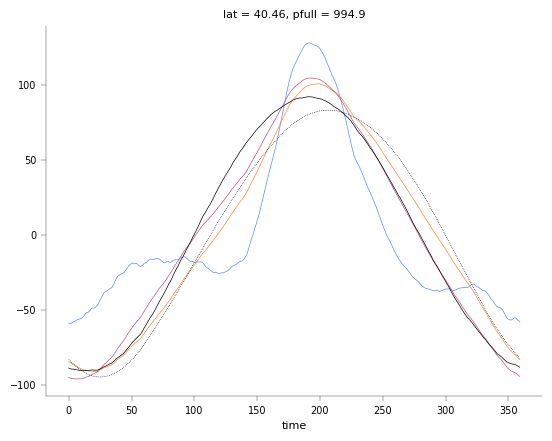

In [152]:
energy_budget_terms['surf_flux']['lambda_const'].plot()
energy_budget_terms['surf_flux']['lambda_a'].plot()
energy_budget_terms['surf_flux']['coef_phase_a'].plot()
energy_budget_terms['surf_flux']['lambda_s'].plot(color='k', linestyle=':')
energy_budget_terms['surf_flux']['simulated'].plot(color='k')

### OLR + Advection

In [179]:
key2 = 'olr_advect'
var = ds.adv_atmos - ds.olr
var = var - var.mean(dim='time')
energy_budget_terms[key2] =  {'simulated': var-var.mean(dim='time')}
error[key2] = {}

param_order = ['B', 'lambda_lw', 'lambda_adv', 'coef_phase_adv', 'coef_phase_olr']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = utils.get_empirical_params(ds, include_params=include_params)
    args_use = update_args(args_base_atmos, feedback_params_use, args_names_atmos)
    energy_budget_terms[key2][key] = utils.get_approx_flux_atmos(**args_use) + \
                                     utils.get_approx_adv_atmos(ds.temp_atm, feedback_params_use['lambda_adv'], feedback_params_use['coef_phase_adv'])
    error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

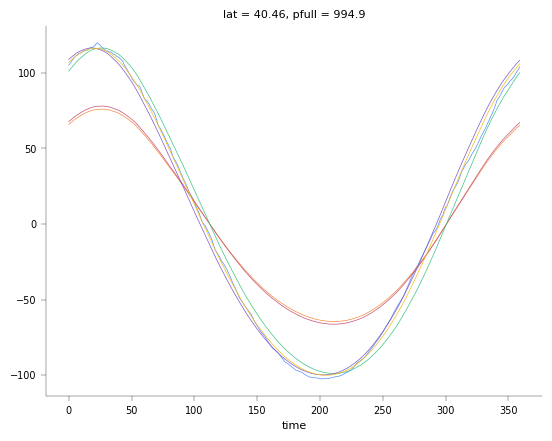

In [183]:
for key in energy_budget_terms[key2]:
    energy_budget_terms[key2][key].plot()

## MSE Tendency
See that phase here actually makes approximtion worse. Maybe because not in annual harmonic?? I used the annual harmonic to obtain the phase factors.

In [217]:
key2 = 'mse_tend'
var = ds.mse_tend_atmos
var = var - var.mean(dim='time')
energy_budget_terms[key2] =  {'simulated': var-var.mean(dim='time')}
error[key2] = {}

# energy_budget_terms[key2]['none'] = utils.get_approx_mse_tend(ds.temp_atm, 1,
#                                                            0, 0,
#                                                            ds.p_integ_calc.mean(dim='time'), ds.time)
# error[key2]['none'] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2]['none'])

param_order = ['coef_amp_col', 'mu', 'coef_phase_col']
include_params = []
for key in param_order:
    include_params.append(key)
    # Only use empirical lambda_const if lambda_a not included
    feedback_params_use = utils.get_empirical_params(ds, include_params=include_params)
    energy_budget_terms[key2][key] = utils.get_approx_mse_tend(ds.temp_atm, feedback_params_use['coef_amp_col'],
                                                               feedback_params_use['coef_phase_col'], feedback_params_use['mu'],
                                                               ds.p_integ_calc.mean(dim='time'), ds.time)
    error[key2][key] = get_error(energy_budget_terms[key2]['simulated'], energy_budget_terms[key2][key])

In [218]:
error[key2]

{'coef_amp_col': <xarray.DataArray (lat: 1)> Size: 8B
 array([29.23083174])
 Coordinates:
   * lat      (lat) float64 8B 40.46
     pfull    float64 8B 994.9,
 'mu': <xarray.DataArray (lat: 1)> Size: 8B
 array([15.91166548])
 Coordinates:
   * lat      (lat) float64 8B 40.46
     pfull    float64 8B 994.9,
 'coef_phase_col': <xarray.DataArray (lat: 1)> Size: 8B
 array([16.25708319])
 Coordinates:
   * lat      (lat) float64 8B 40.46
     pfull    float64 8B 994.9}

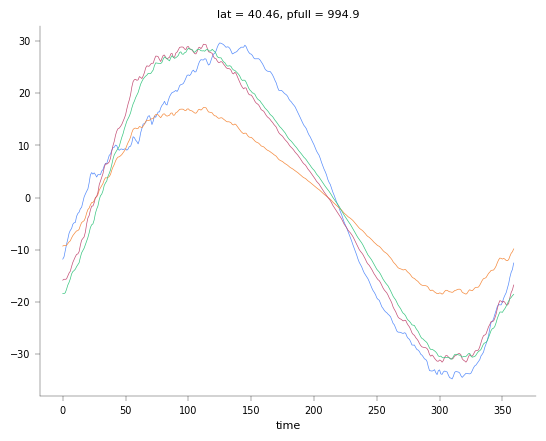

In [220]:
energy_budget_terms[key2]['simulated'].plot()
# energy_budget_terms[key2]['none'].plot()
energy_budget_terms[key2]['coef_amp_col'].plot()
energy_budget_terms[key2]['mu'].plot()
energy_budget_terms[key2]['coef_phase_col'].plot()
# energy_budget_terms[key2]['coef_amp_col'].plot()
# energy_budget_terms[key2]['coef_phase_col'].plot()